<center>Universidade Federal de Viçosa</center>
<center>Coordenadoria de Educação Aberta e a Distância</center>
<center>Inteligência Artificial e Computacional</center>
<center>ELT578 - Análise de Imagens e Visão Computacional</center>

**<center>AULA PRÁTICA 3: Técnicas de Filtragem </center>**

Nesta prática, vamos estudar técnicas de filtragem em imagens digitais, tanto no domínio espacial quanto no domínio da frequência. As aplicações incluem:

*   Correlação e convolução (com máscaras/kernels);
*   Adição de ruído (Salt & Pepper e Gaussiano);
*   Suavização (blur/borramento);
*   Detecção de bordas (Sobel).
*   Filtros passa-alta e passa-baixa (domínio da frequência).


### 1 Configurações iniciais

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### 1.2) Importando bibliotecas

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from matplotlib import pyplot as plt

# 2 Filtragem por Correlação

In [ ]:
# Definição de uma matriz de imagem (5x5 pixels, escala de cinza)
I = np.array([
 [1,1,5,0,3],
 [4,3,0,1,4],
 [0,1,4,1,5],
 [0,1,3,0,4],
 [0,5,0,1,1]
], dtype='uint8')

# Definição de um filtro (máscara 3x3)
F = np.array([
 [1,1,1],
 [2,1,3],
 [1,0,2]
], dtype='uint8')

print(I)
print(F)
print(I.shape)


[[1 1 5 0 3]
 [4 3 0 1 4]
 [0 1 4 1 5]
 [0 1 3 0 4]
 [0 5 0 1 1]]
[[1 1 1]
 [2 1 3]
 [1 0 2]]
(5, 5)


In [ ]:
I_F1 = cv2.filter2D(I, -1, F)
I_F2 = cv2.filter2D(I, -1, F, borderType=cv2.BORDER_REFLECT_101)
I_F3 = cv2.filter2D(I, -1, F, borderType=cv2.BORDER_CONSTANT)
print(I_F1)
print(I_F2)
print(I_F3)

#cv2.BORDER_CONSTANT
#cv2.BORDER_REFLECT
#cv2.BORDER_REFLECT_101
#cv2.BORDER_REPLICATE
#cv2.BORDER_WRAP

[[25 29 16 32 12]
 [25 26 18 35 15]
 [18 26 14 40 16]
 [22 15 18 30 14]
 [30 15 18 22 10]]
[[25 29 16 32 12]
 [25 26 18 35 15]
 [18 26 14 40 16]
 [22 15 18 30 14]
 [30 15 18 22 10]]
[[10 22 12 27  4]
 [17 26 18 35 10]
 [12 26 14 40 12]
 [14 15 18 30 11]
 [16  9 17 11  7]]


**cv2.BORDER_CONSTANT**

Preenche a borda com um valor constante (ex: 0 ou a cor especificada).
Exemplo: [1,2,3] → [0,0,|1,2,3|,0,0]

**cv2.BORDER_REFLECT**

Reflete os pixels da borda sem repetir o último pixel.
Exemplo: [1,2,3] → [2,1,|1,2,3|,3,2]

**cv2.BORDER_REFLECT_101  # (ou cv2.BORDER_DEFAULT)**

Reflete a imagem, mas sem duplicar o pixel da borda.
Exemplo: [1,2,3] → [3,2,|1,2,3|,2,1]

**cv2.BORDER_REPLICATE**

Repete o valor dos pixels da borda.
Exemplo: [1,2,3] → [1,1,|1,2,3|,3,3]

**cv2.BORDER_WRAP**

“Enrola” a imagem, conectando as bordas opostas.
Exemplo: [1,2,3] → [3,2,|1,2,3|,1,2]


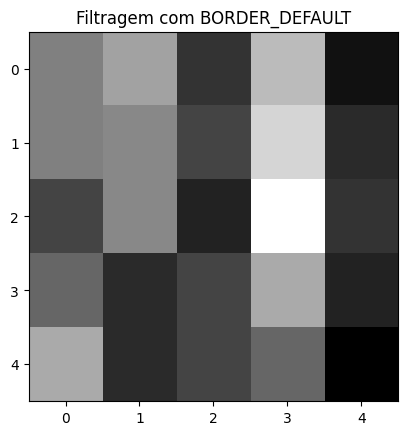

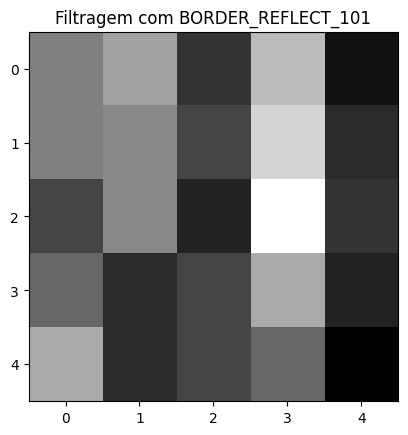

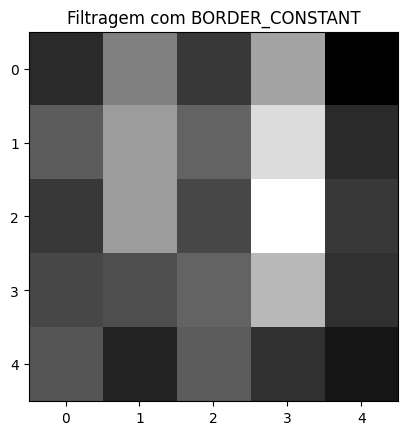

In [ ]:
plt.imshow(I_F1, cmap='gray')
plt.title("Filtragem com BORDER_DEFAULT")
plt.show()

plt.imshow(I_F2, cmap='gray')
plt.title("Filtragem com BORDER_REFLECT_101")
plt.show()

plt.imshow(I_F3, cmap='gray')
plt.title("Filtragem com BORDER_CONSTANT")
plt.show()


# 3 Adição de Ruídos

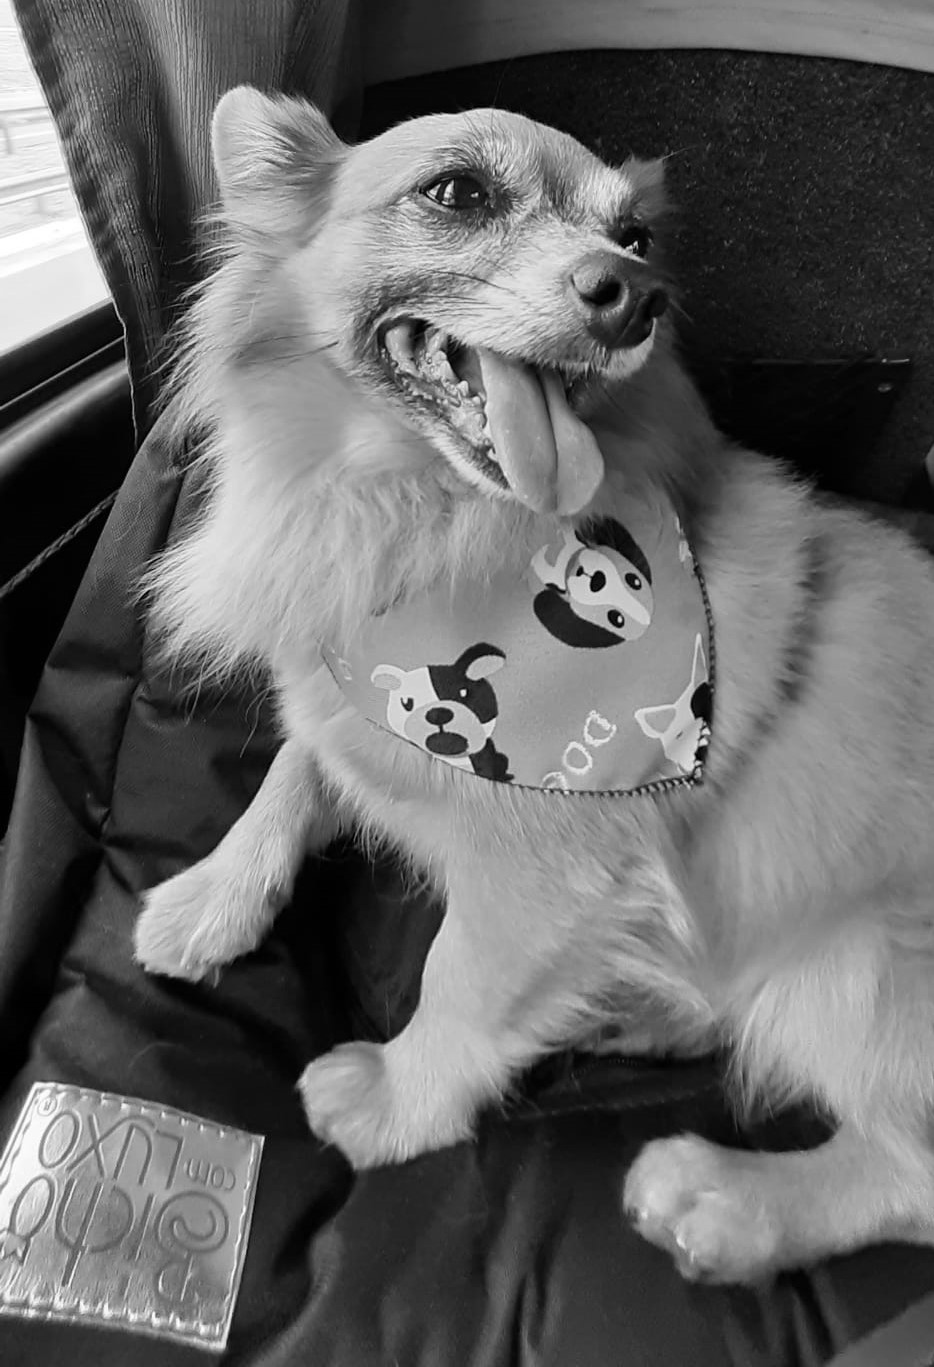

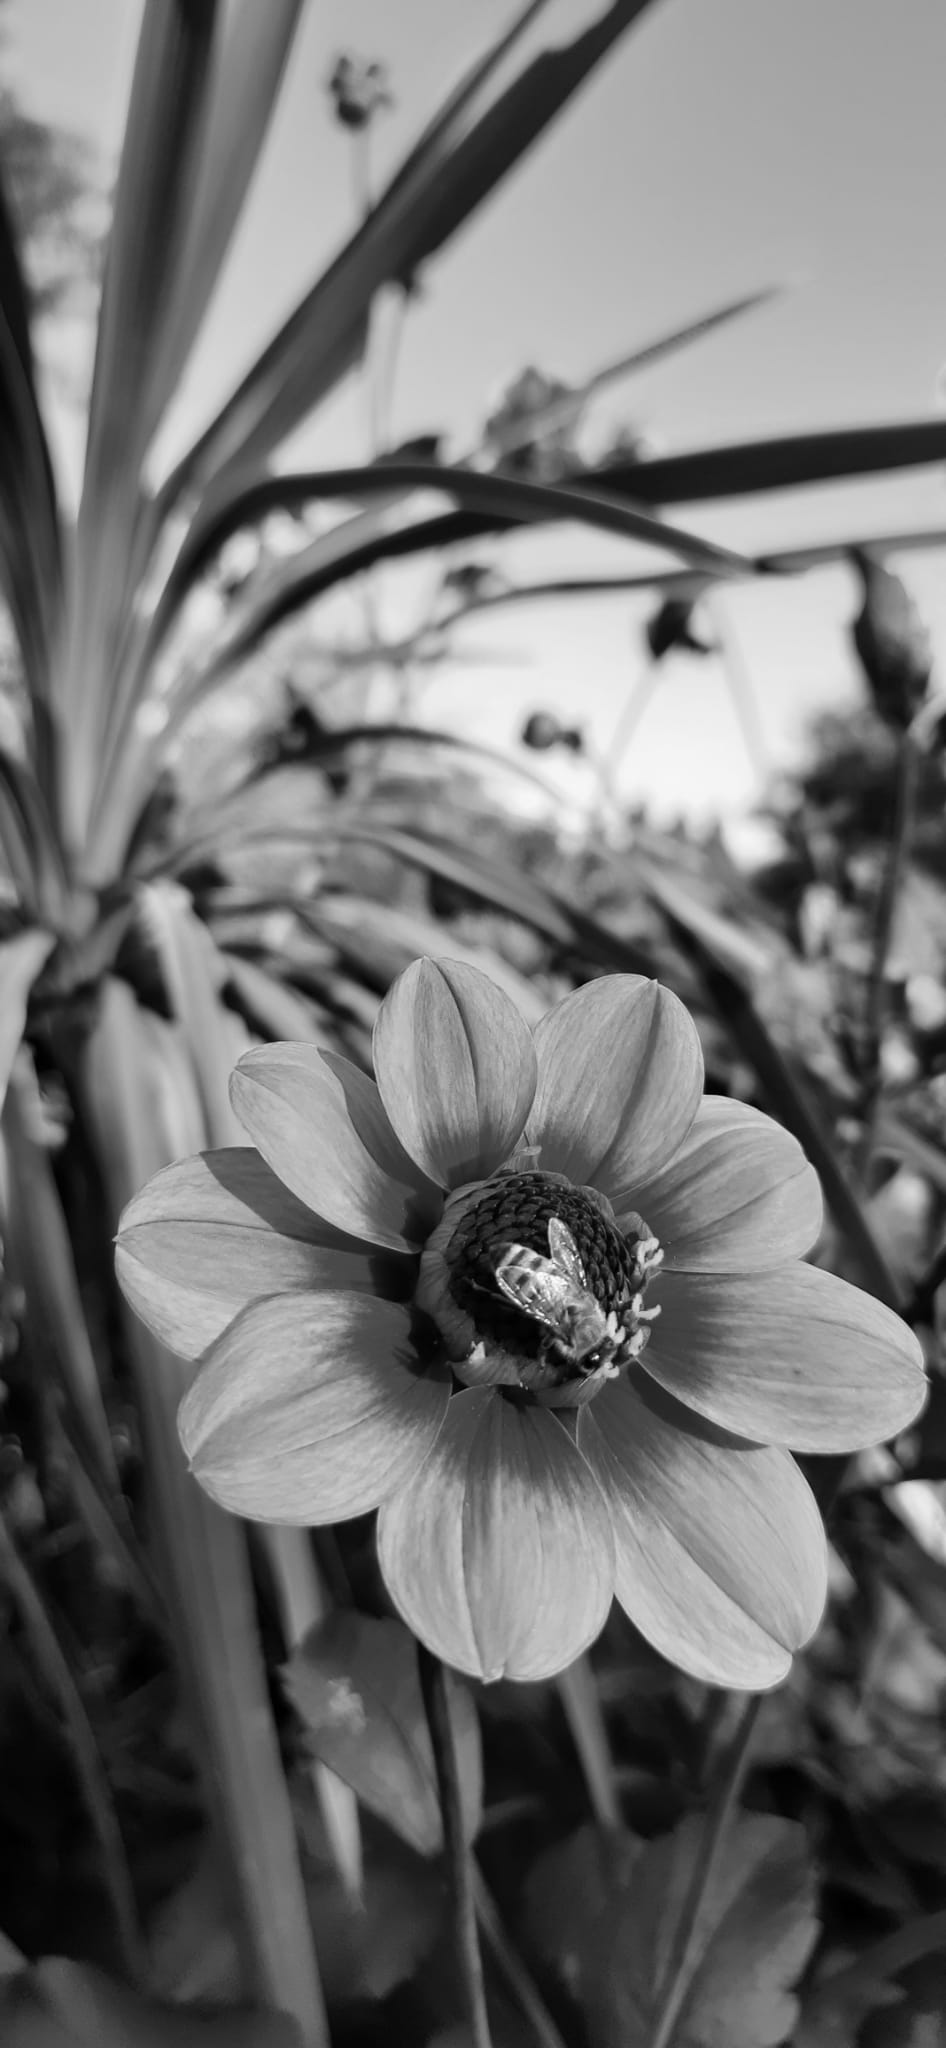

In [ ]:
dog = cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/dog.jpeg',0)
flower = cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/flower.jpeg', 0)

cv2_imshow(dog)
cv2_imshow(flower)

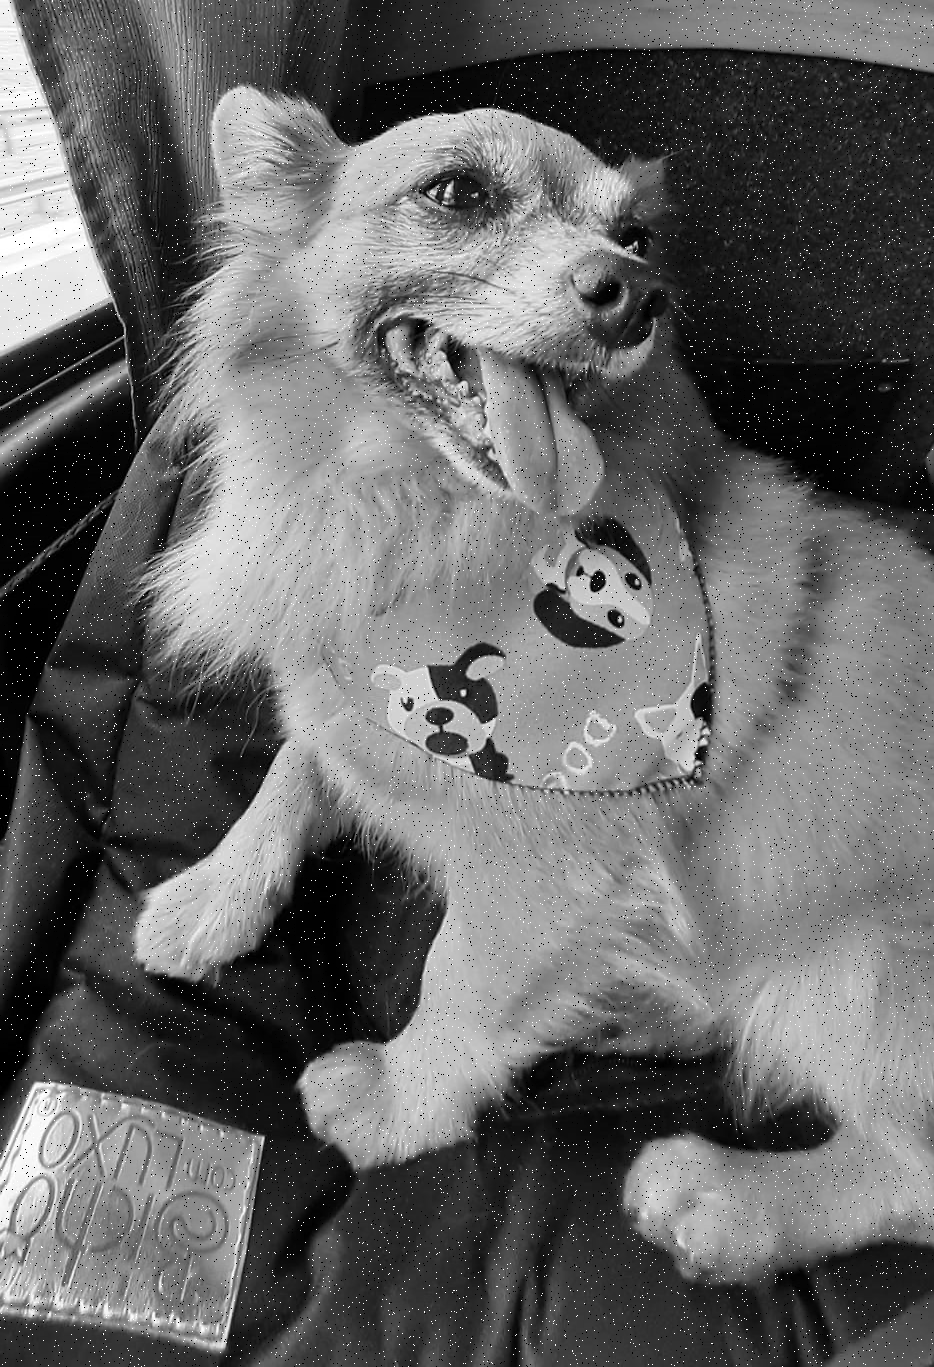

In [ ]:
#Salt & Pepper (Chuvisco)
def add_chuvisco(original, controle):
    ruido = np.random.rand(original.shape[0], original.shape[1])
    ruidosa = original.copy()
    ruidosa[ruido < controle] = 0       # pontos pretos
    ruidosa[ruido > 1-controle] = 255   # pontos brancos
    return ruidosa

dog_chuvisco = add_chuvisco(dog, 0.01)
cv2_imshow(dog_chuvisco)


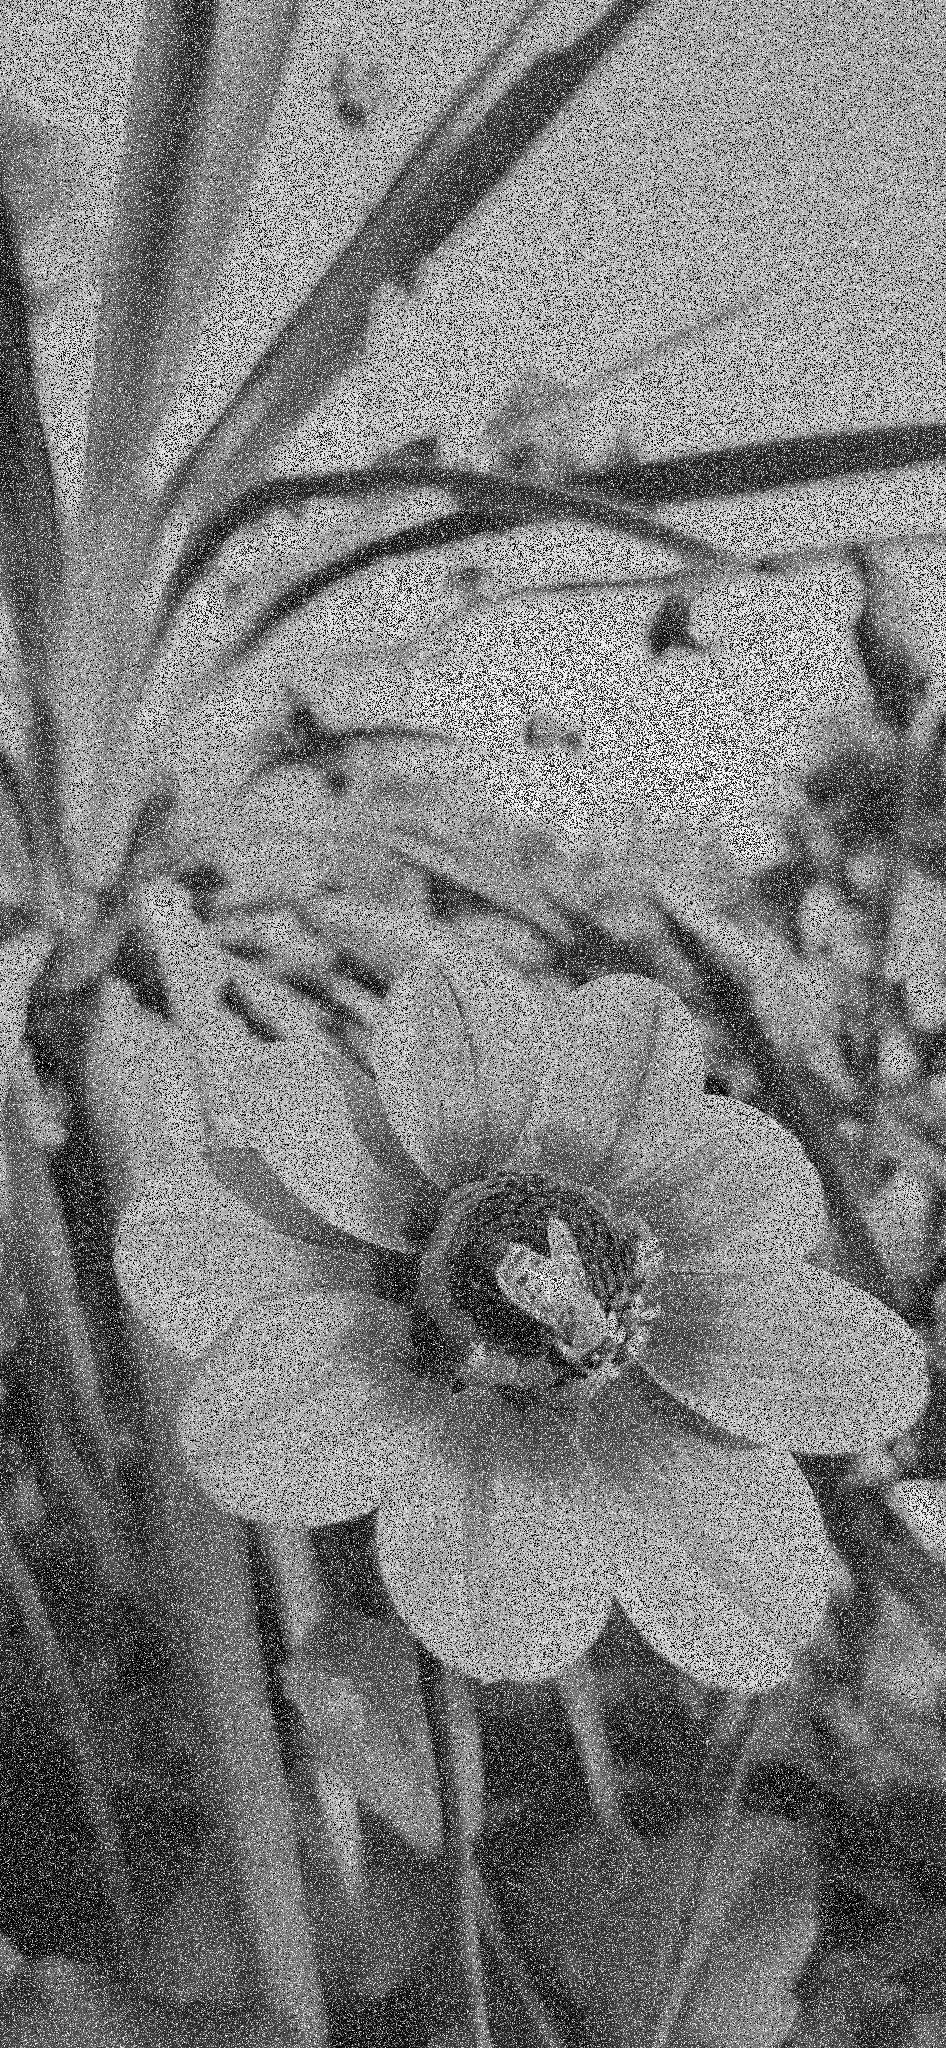

In [ ]:
def add_gauss(original, media, dp):
    ruido = np.zeros(original.shape, np.uint8)
    cv2.randn(ruido, media, dp)      # ruído normal
    ruidosa = np.add(original, ruido)
    return ruidosa

flower_gauss = add_gauss(flower, 0, 100)
cv2_imshow(flower_gauss)


# 4 Suavização (Borramento)

In [ ]:
dog_S = cv2.blur(dog, (7,7))              # Blur simples
flower_S = cv2.blur(flower, (3,3))

dog_CS = cv2.blur(dog_chuvisco, (3,3))    # Remove salt & pepper
flower_GS = cv2.blur(flower_gauss, (3,3)) # Remove ruído gaussiano


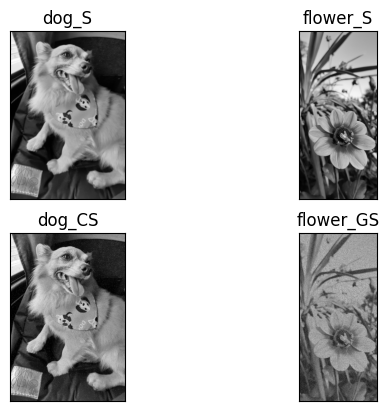

In [ ]:
titulos = ['dog_S','flower_S','dog_CS','flower_GS']
imagens = [dog_S, flower_S, dog_CS, flower_GS]

for i in range(4):
    plt.subplot(2,2,i+1), plt.imshow(cv2.cvtColor(imagens[i], cv2.COLOR_BGR2RGB))
    plt.title(titulos[i])
    plt.xticks([]), plt.yticks([])
plt.show()


# 5 Sobel – Realce de Bordas

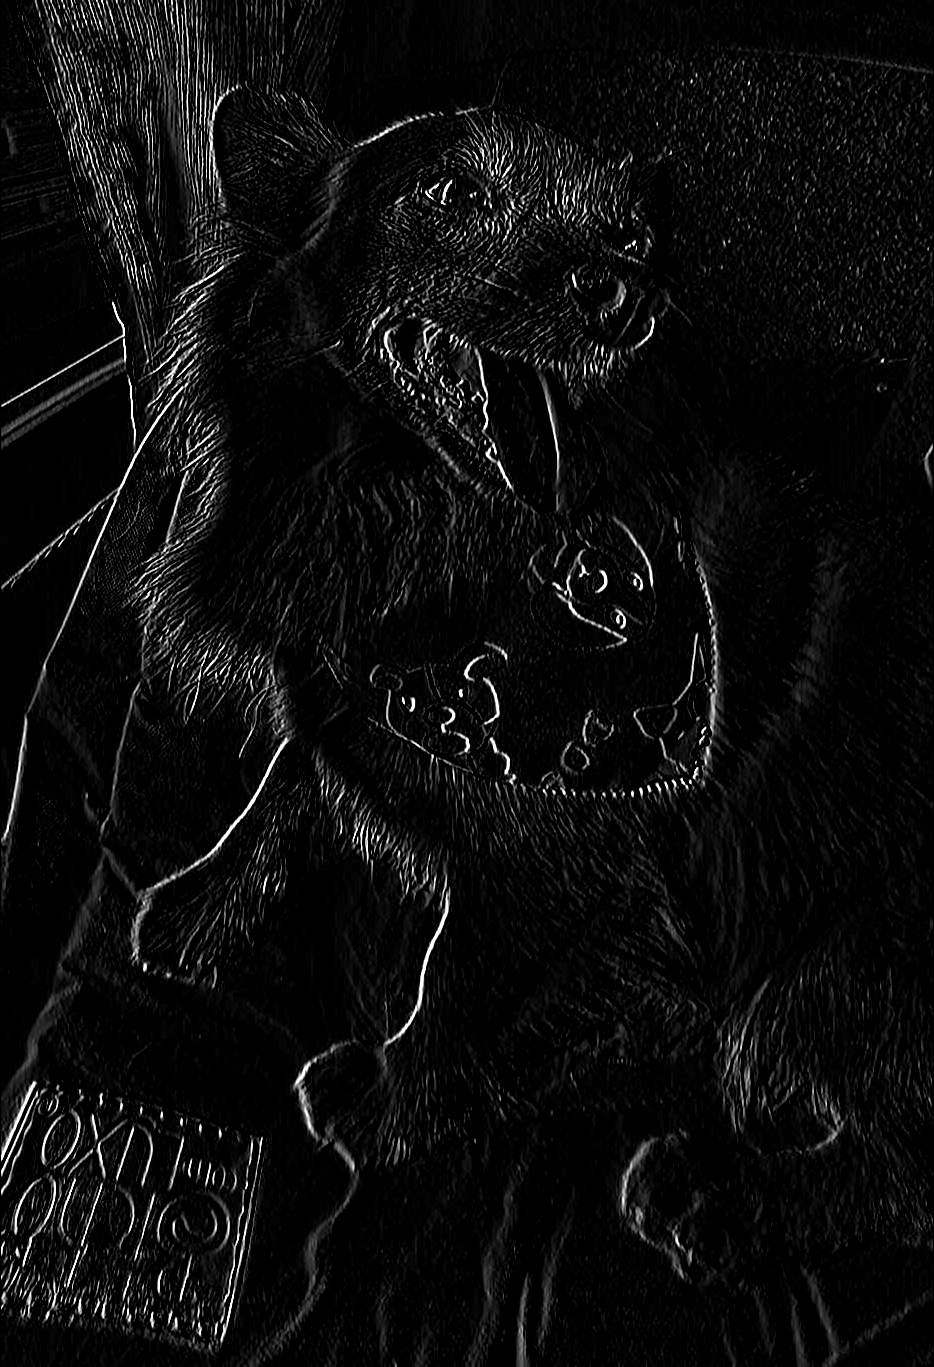

In [ ]:
dog_sobel = cv2.Sobel(dog, -1, 1, 0)  # derivada em X (bordas verticais)

#1, 0: Estes são os dois últimos argumentos, dx e dy, respectivamente.
#Eles especificam a ordem da derivada nas direções x e y.
#Um valor de 1 para dx significa que o filtro Sobel calculará a derivada de primeira ordem na direção x (gradiente horizontal),
# e um valor de 0 para dy significa que não calculará a derivada na direção y (gradiente vertical).
#O resultado desta operação será uma imagem que destaca as bordas na direção horizontal (ou seja, bordas que são predominantemente verticais na imagem original).
#Isso pode ser útil para várias tarefas de visão computacional e processamento de imagens, como detecção de bordas ou extração de recursos.

dog_sobel = (dog_sobel.astype(float) - dog_sobel.min()) / (dog_sobel.max()-dog_sobel.min()) * 255
dog_sobel = np.uint8(dog_sobel)

cv2_imshow(dog_sobel)

# 6 Filtros passa-alta e passa-baixa (domínio da frequência)

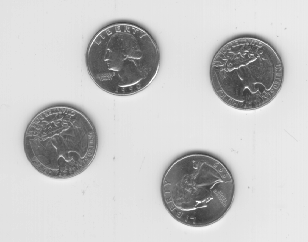

(Text(0.5, 1.0, 'Passa-alta'),
 (np.float64(-0.5), np.float64(307.5), np.float64(241.5), np.float64(-0.5)))

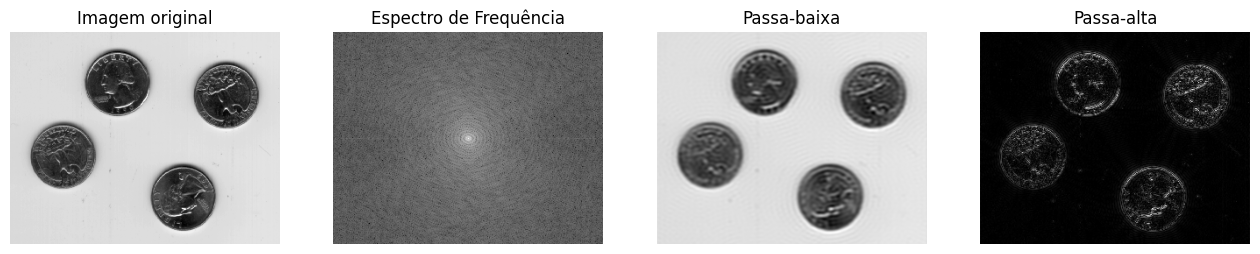

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# 1. Leitura da imagem em escala de cinza
img = cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/quarter.tif', 0)
cv2_imshow(img)

# 2. Transformada de Fourier 2D
f = np.fft.fft2(img)                     # Calcula a FFT da imagem
fshift = np.fft.fftshift(f)              # Desloca o espectro para que as baixas frequências fiquem no centro.

# 3. Criação das máscaras
rows, cols = img.shape
crow, ccol = rows//2 , cols//2           # Centro da imagem
r = 50                                   # Raio do filtro (ajustável): controla a suavização: quanto maior, mais detalhes são mantidos; quanto menor, mais borrada a imagem.

# Passa-baixa: mantém o círculo central
mask_low = np.zeros((rows, cols), np.uint8)
cv2.circle(mask_low, (ccol, crow), r, 1, -1) #1 → mantém as frequências dentro do raio (baixas).

# Passa-alta: inverte a máscara (zera o círculo central, mantém as altas frequências)
mask_high = 1 - mask_low

# 4. Aplicação das máscaras
fshift_low = fshift * mask_low #No domínio da frequência, aplicar um filtro é simplesmente multiplicar os coeficientes pelo fator da máscara.
fshift_high = fshift * mask_high

# 5. Transformada inversa para voltar ao domínio espacial
img_low = np.fft.ifft2(np.fft.ifftshift(fshift_low))
img_low = np.abs(img_low) #garante que o resultado seja real e não complexo.

img_high = np.fft.ifft2(np.fft.ifftshift(fshift_high))
img_high = np.abs(img_high) #garante que o resultado seja real e não complexo.

# 6. Exibição dos resultados
plt.figure(figsize=(16,8))

plt.subplot(141), plt.imshow(img, cmap='gray')
plt.title('Imagem original'), plt.axis('off')

plt.subplot(142), plt.imshow(np.log(1+np.abs(fshift)), cmap='gray') #em escala logarítmica para melhor visualização
plt.title('Espectro de Frequência'), plt.axis('off')

plt.subplot(143), plt.imshow(img_low, cmap='gray')
plt.title('Passa-baixa'), plt.axis('off')

plt.subplot(144), plt.imshow(img_high, cmap='gray')
plt.title('Passa-alta'), plt.axis('off')


#O filtro passa-baixa elimina os detalhes finos (altas frequências), resultando em uma imagem mais suavizada.
#Alterando o raio r, podemos controlar o grau de suavização:
#Raio pequeno → imagem mais borrada.
#Raio grande → mantém mais detalhes.
#Se invertermos a máscara (mask = 1 - mask), obtemos um filtro passa-alta, que remove estruturas grandes e mantém apenas as bordas e detalhes finos.

**DESAFIO**

- Aplicar filtros passa-alta e passa baixa para uma imagem RGB

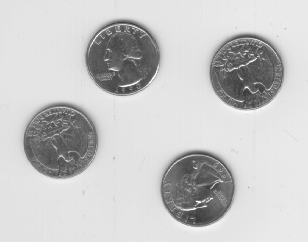

In [ ]:
# 1. Leitura da imagem em escala de cinza
img = cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/quarter.tif', 1)
cv2_imshow(img)

In [ ]:
# 2. Transformada de Fourier 2D
f = np.fft.fft2(img)                     # Calcula a FFT da imagem
fshift = np.fft.fftshift(f)              # Desloca o espectro para que as baixas frequências fiquem no centro.

In [ ]:
np.ndim(fshift), np.ndim(mask_low)

(3, 2)

In [ ]:
# 3. Criação das máscaras
rows, cols, dim = img.shape
crow, ccol = rows//2 , cols//2           # Centro da imagem
r = 50                                   # Raio do filtro (ajustável): controla a suavização: quanto maior, mais detalhes são mantidos; quanto menor, mais borrada a imagem.

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
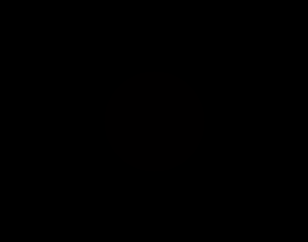

In [ ]:
# Passa-baixa: mantém o círculo central
mask_low = np.zeros((rows, cols, dim), np.uint8)
cv2.circle(mask_low, (ccol, crow), r, 1, -1) #1 → mantém as frequências dentro do raio (baixas).

In [ ]:
# Passa-alta: inverte a máscara (zera o círculo central, mantém as altas frequências)
mask_high = 1 - mask_low

# 4. Aplicação das máscaras
fshift_low = fshift * mask_low #No domínio da frequência, aplicar um filtro é simplesmente multiplicar os coeficientes pelo fator da máscara.
fshift_high = fshift * mask_high


In [ ]:
# 5. Transformada inversa para voltar ao domínio espacial
img_low = np.fft.ifft2(np.fft.ifftshift(fshift_low))
img_low = np.abs(img_low) #garante que o resultado seja real e não complexo.

img_high = np.fft.ifft2(np.fft.ifftshift(fshift_high))
img_high = np.abs(img_high) #garante que o resultado seja real e não complexo.

(Text(0.5, 1.0, 'Passa-alta'),
 (np.float64(-0.5), np.float64(307.5), np.float64(241.5), np.float64(-0.5)))

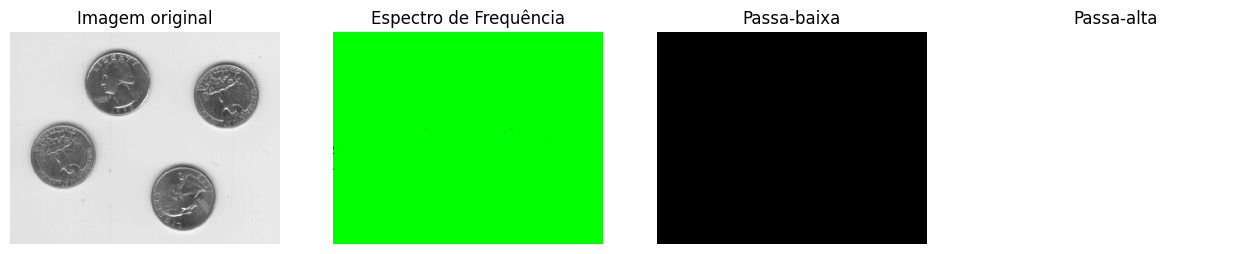

In [ ]:
# 6. Exibição dos resultados
plt.figure(figsize=(16,8))

plt.subplot(141), plt.imshow(img, cmap='gray')
plt.title('Imagem original'), plt.axis('off')

plt.subplot(142), plt.imshow(np.log(1+np.abs(fshift)), cmap='gray') #em escala logarítmica para melhor visualização
plt.title('Espectro de Frequência'), plt.axis('off')

plt.subplot(143), plt.imshow(img_low, cmap='gray')
plt.title('Passa-baixa'), plt.axis('off')

plt.subplot(144), plt.imshow(img_high, cmap='gray')
plt.title('Passa-alta'), plt.axis('off')

In [ ]:
#O filtro passa-baixa elimina os detalhes finos (altas frequências), resultando em uma imagem mais suavizada.
#Alterando o raio r, podemos controlar o grau de suavização:
#Raio pequeno → imagem mais borrada.
#Raio grande → mantém mais detalhes.
#Se invertermos a máscara (mask = 1 - mask), obtemos um filtro passa-alta, que remove estruturas grandes e mantém apenas as bordas e detalhes finos.